# Benchmark: Baseline (dataset original) vs Preprocess (dataset pré-processado)

Modelos: YOLO26m, 125 épocas, pesos versionados em `irlvinicius/KaryoVisio` (Hugging Face).

**Protocolo:** mesmo split de teste (mesmas imagens, uma versão original e outra pré-processada), mesmos `conf`/`IoU`/`imgsz` (ver `_shared/eval_config.yaml`).

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..') / '_shared'))

import utils
from IPython.display import display, Image

cfg = utils.load_eval_config()
RESULTS = Path('results')
SHARED = Path('..') / '_shared'
cfg

{'split': 'test',
 'imgsz': 640,
 'batch': 16,
 'conf': 0.001,
 'iou': 0.7,
 'seed': 0}

## 1. Configuração dos modelos

In [2]:
DATA = str(SHARED / 'dataset.yaml')  # mesmo dataset para todos os modelos

MODELS = {
    'baseline':   'models/yolo26m-original/model/best.pt',
    'preprocess': 'models/yolo26m-preprocessed/model/best.pt',
}

## 2. Avaliação

In [5]:
import pandas as pd

FORCE_REEVAL = True   # True para reavaliar tudo do zero

csv_path = RESULTS / 'metrics_table.csv'
if csv_path.exists() and not FORCE_REEVAL:
    df = pd.read_csv(csv_path, index_col='Modelo')
    print('Usando métricas salvas em', csv_path)
else:
    rows = []
    for name, weights_in_repo in MODELS.items():
        w = utils.get_weights(weights_in_repo)
        rows.append(utils.evaluate(name, w, DATA, cfg, out_dir=RESULTS))
    df = utils.metrics_table(rows)
    df.to_csv(csv_path)

df

Ultralytics 8.4.38 🚀 Python-3.12.8 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 4096MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 218.7±50.2 MB/s, size: 90.2 KB)
val: Scanning /home/irlvinicius/CytoML/data/processed/24_chromosomes_object/labels/test.cache... 749 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 749/749 112.2Mit/s 0.0s
val: /home/irlvinicius/CytoML/data/processed/24_chromosomes_object/images/test/1060171.jpg: 1 duplicate labels removed
val: /home/irlvinicius/CytoML/data/processed/24_chromosomes_object/images/test/1060181.jpg: 1 duplicate labels removed
val: /home/irlvinicius/CytoML/data/processed/24_chromosomes_object/images/test/1060241.jpg: 1 duplicate labels removed
val: /home/irlvinicius/CytoML/data/processed/24_chromosomes_object/images/test/1060633.jpg: 1 duplicate labels removed
val: /home/irlvinicius/CytoML/data/processed/24_chromosomes_object/images/test/10607

,mAP50,mAP50-95,Precision,Recall,F1,Inferência (ms/img)
Modelo,,,,,,
baseline,0.9935,0.8137,0.9841,0.9861,0.9851,175.6582
preprocess,0.9938,0.8709,0.9885,0.9875,0.9880,181.2107


## 3. Tabela e gráfico comparativo

In [6]:
df.to_csv(RESULTS / 'metrics_table.csv')
df.to_markdown(RESULTS / 'metrics_table.md')

utils.plot_comparison(df, save_path=RESULTS / 'metrics_comparison.png')

<Axes: title={'center': 'Comparação de métricas'}, ylabel='Valor'>

## 4. Curvas e matrizes de confusão

baseline


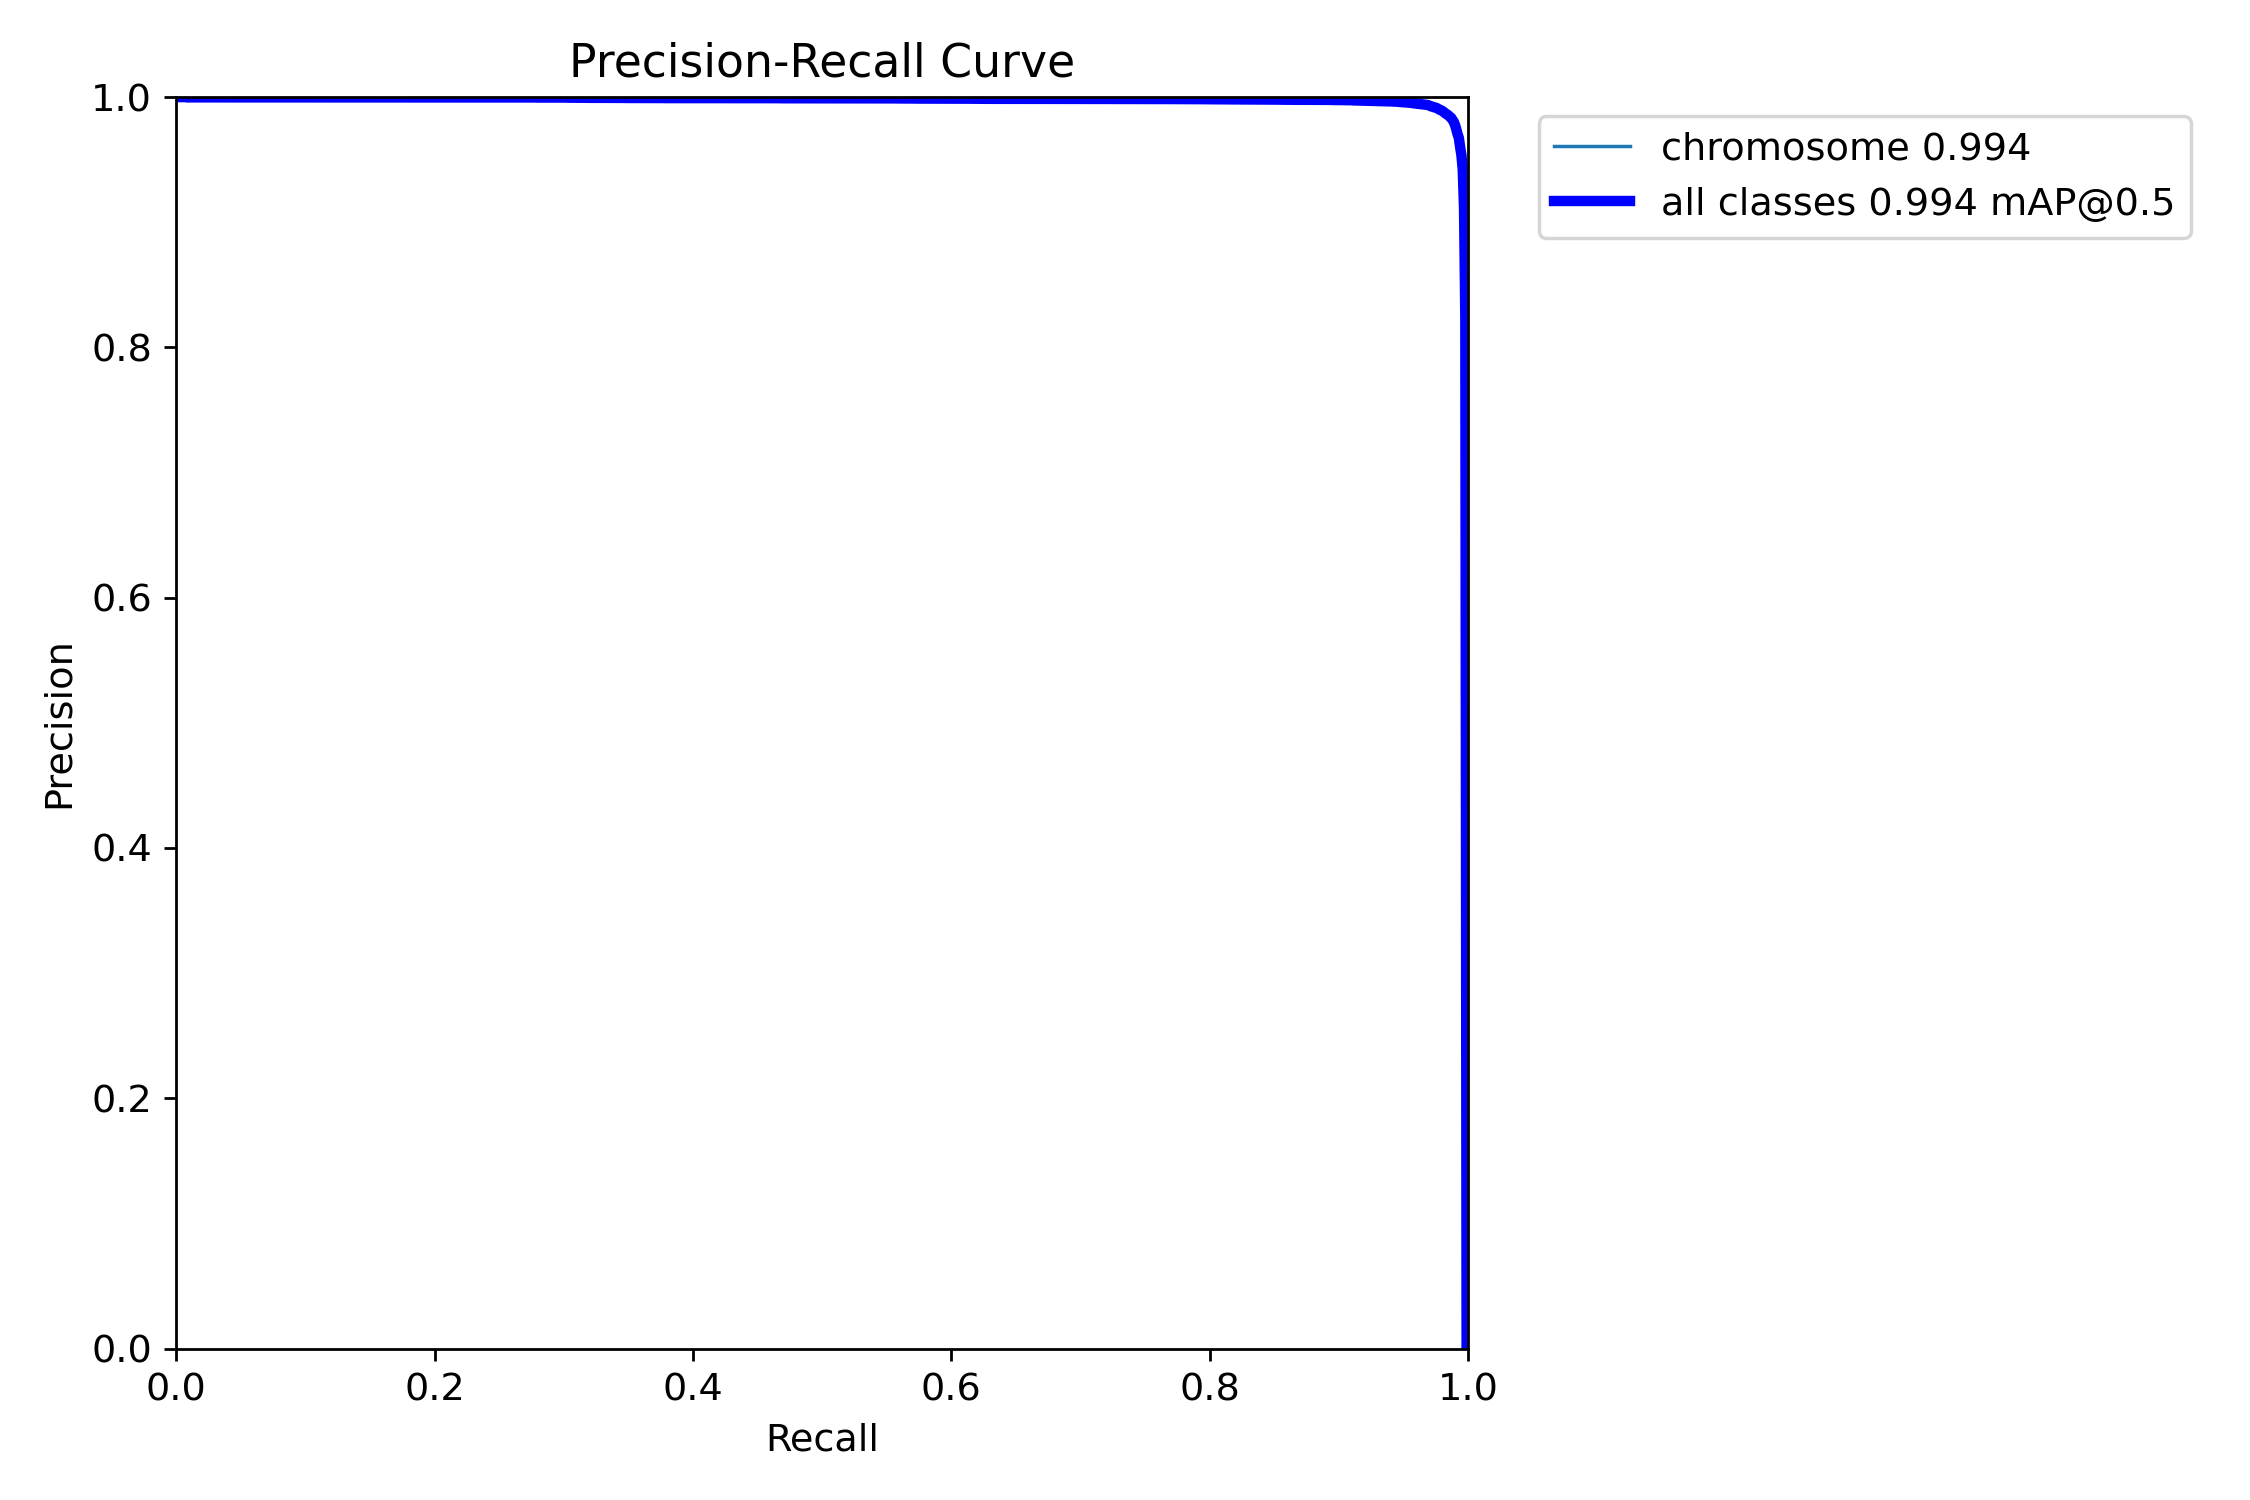

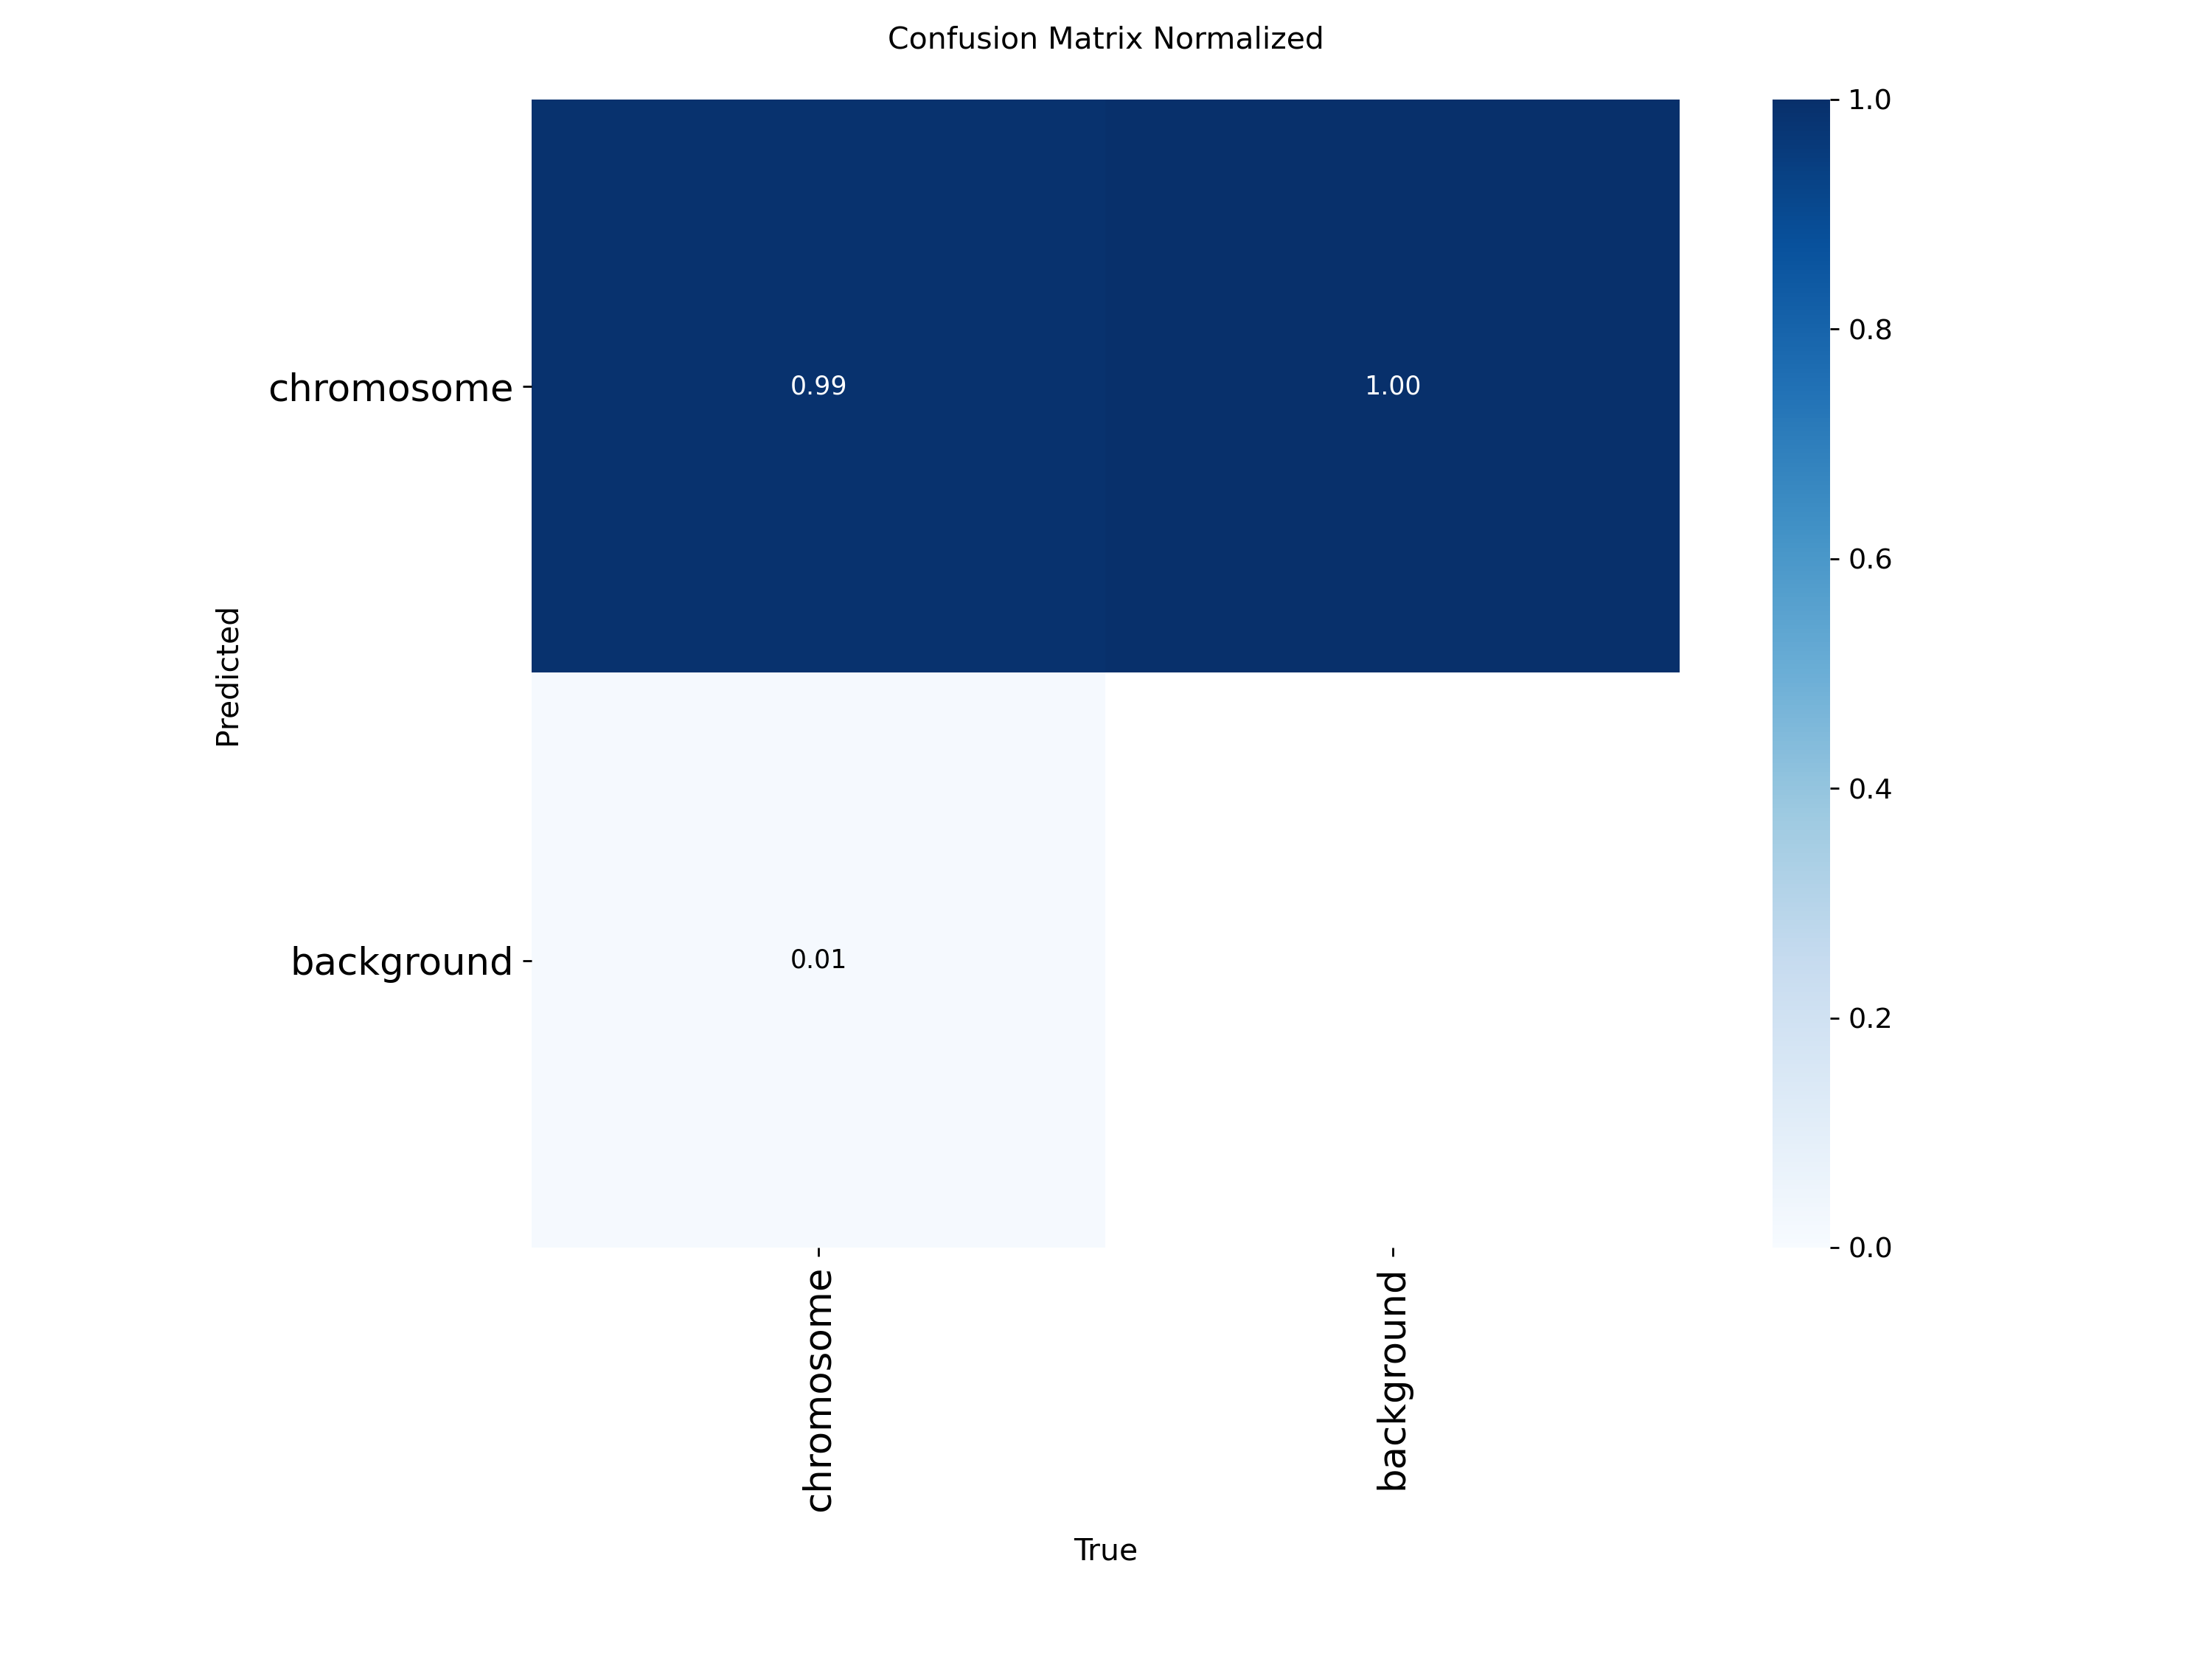

preprocess


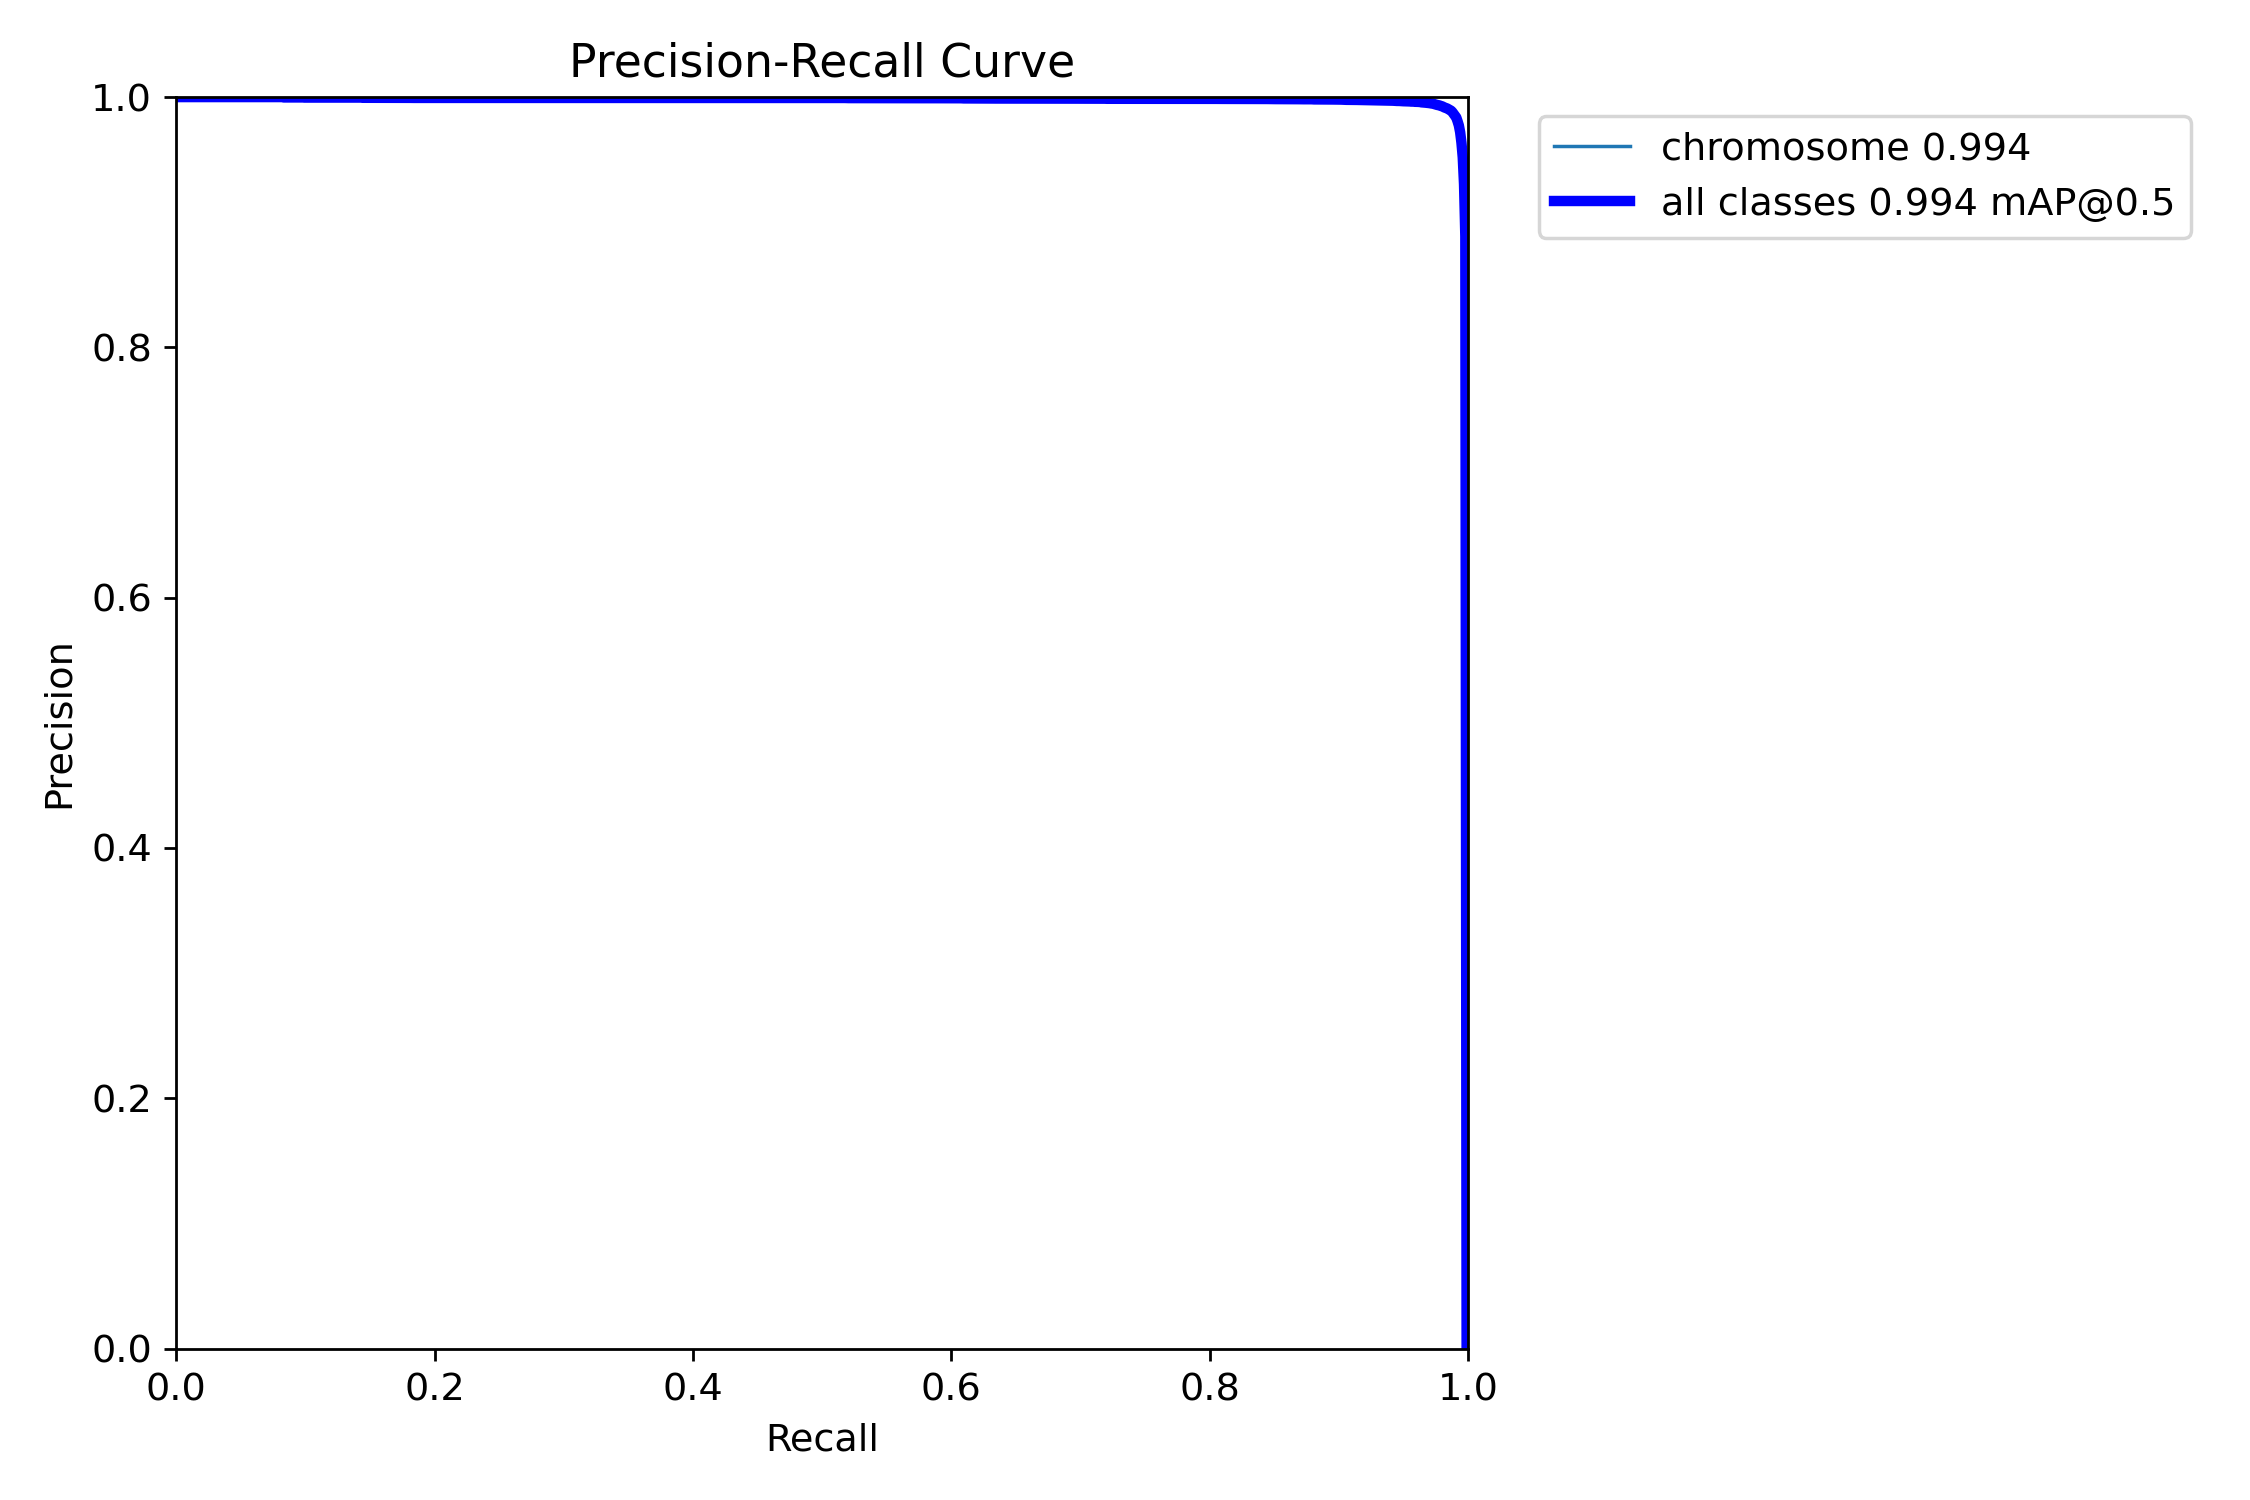

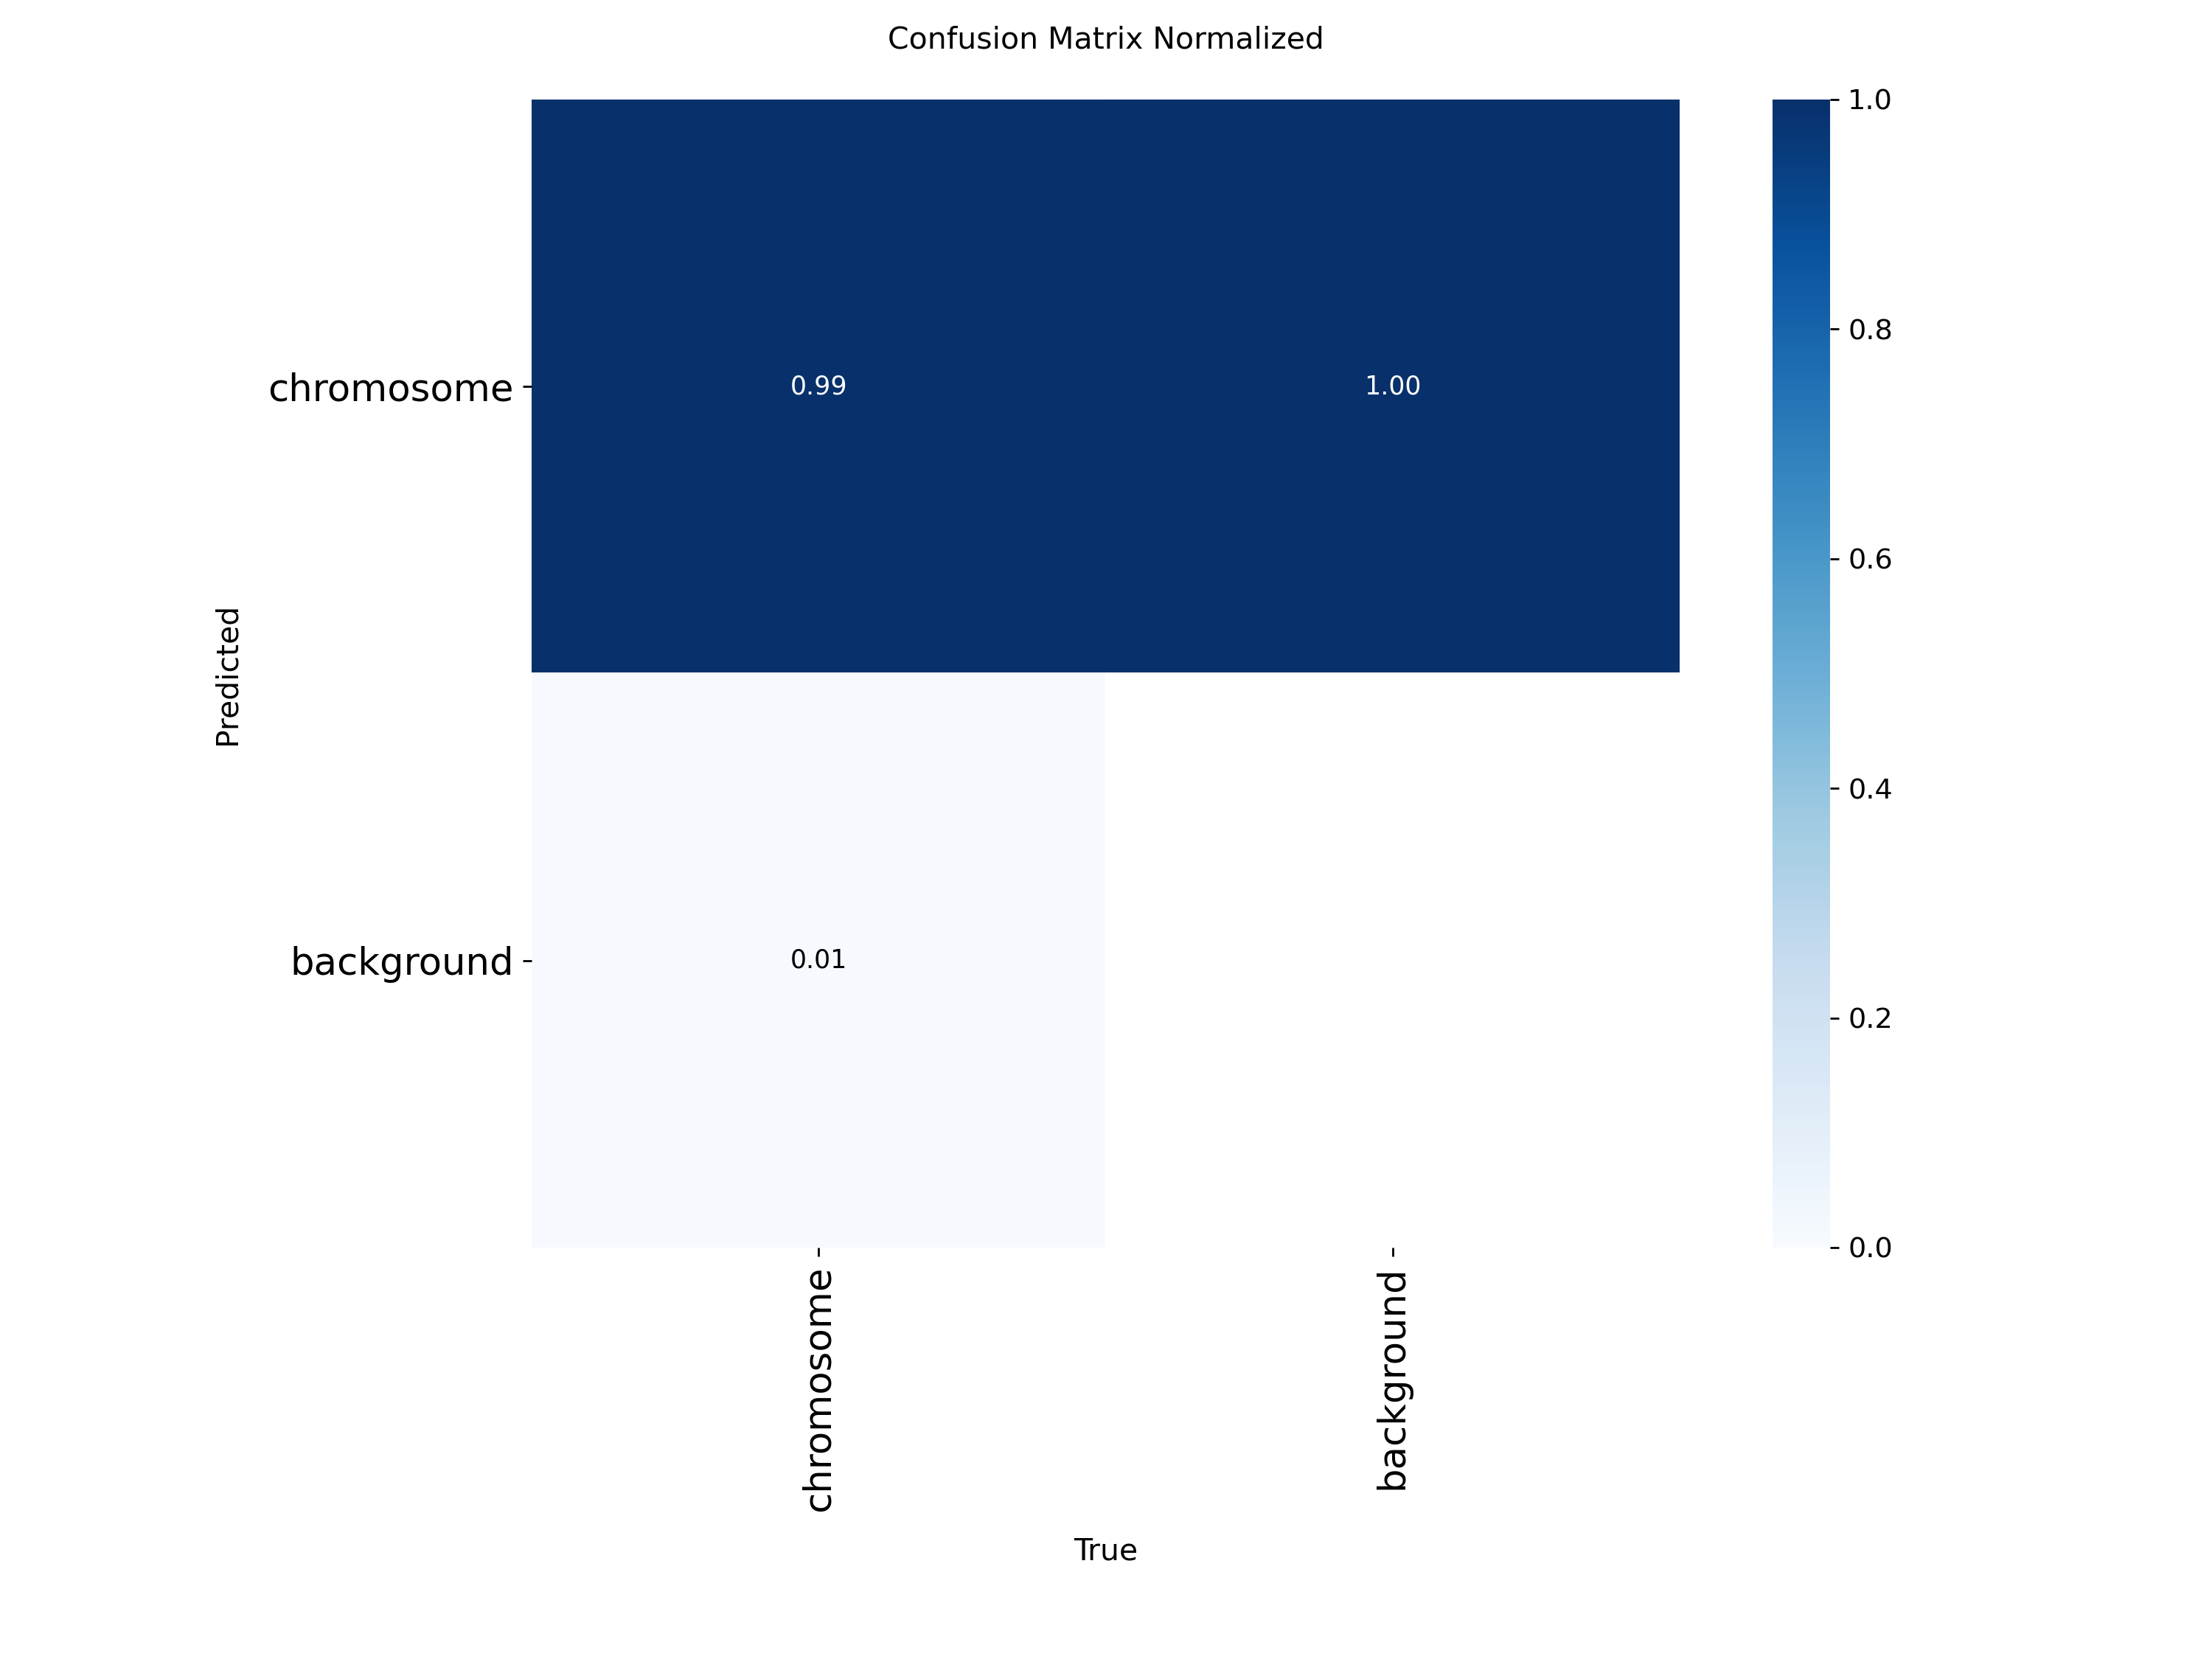

In [7]:
for name in MODELS:
    print(name)
    for f in ['BoxPR_curve.png', 'confusion_matrix_normalized.png']:
        p = RESULTS / name / f
        if p.exists():
            display(Image(filename=p, width=450))